✓ Reproducibility block applied (SEED=42)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ STAGE_DIR : /content/drive/MyDrive/NLP FINAL/rq8_master_evaluation
✓ All source CSVs found (read-only mode — no retraining)
✓ Master table: 8 models


,Model,Family,Stage,Accuracy,Precision,Recall,Macro-F1,ROC-AUC,PR-AUC,Phishing Recall
0,DistilBERT,Transformer,RQ6,0.9753,0.9564,0.9818,0.9742,0.9974,0.9952,0.9818
1,Linear SVM,Margin-based,RQ4,0.9699,0.9431,0.9827,0.9687,0.9945,0.9912,0.9827
2,TextCNN,Convolutional (Deep Learning),RQ5,0.9682,0.9468,0.9735,0.9668,0.9940,0.9882,0.9735
3,Logistic Regression,Linear,RQ4,0.9664,0.9395,0.9772,0.9650,0.9923,0.9867,0.9772
4,Random Forest,Tree ensemble (bagging),RQ4,0.9606,0.9386,0.9626,0.9589,0.9924,0.9871,0.9626
5,XGBoost,Tree ensemble (boosting),RQ4,0.9574,0.9244,0.9708,0.9557,0.9927,0.9865,0.9708
6,Multinomial Naive Bayes,Probabilistic,RQ4,0.9567,0.9280,0.9644,0.9549,0.9916,0.9850,0.9644
7,BiLSTM,Recurrent (Deep Learning),RQ5,0.9374,0.9160,0.9252,0.9344,0.9831,0.9675,0.9252


✓ Loaded test predictions for 8 models  (n=2,795)

[1/3] Grouped bar chart...


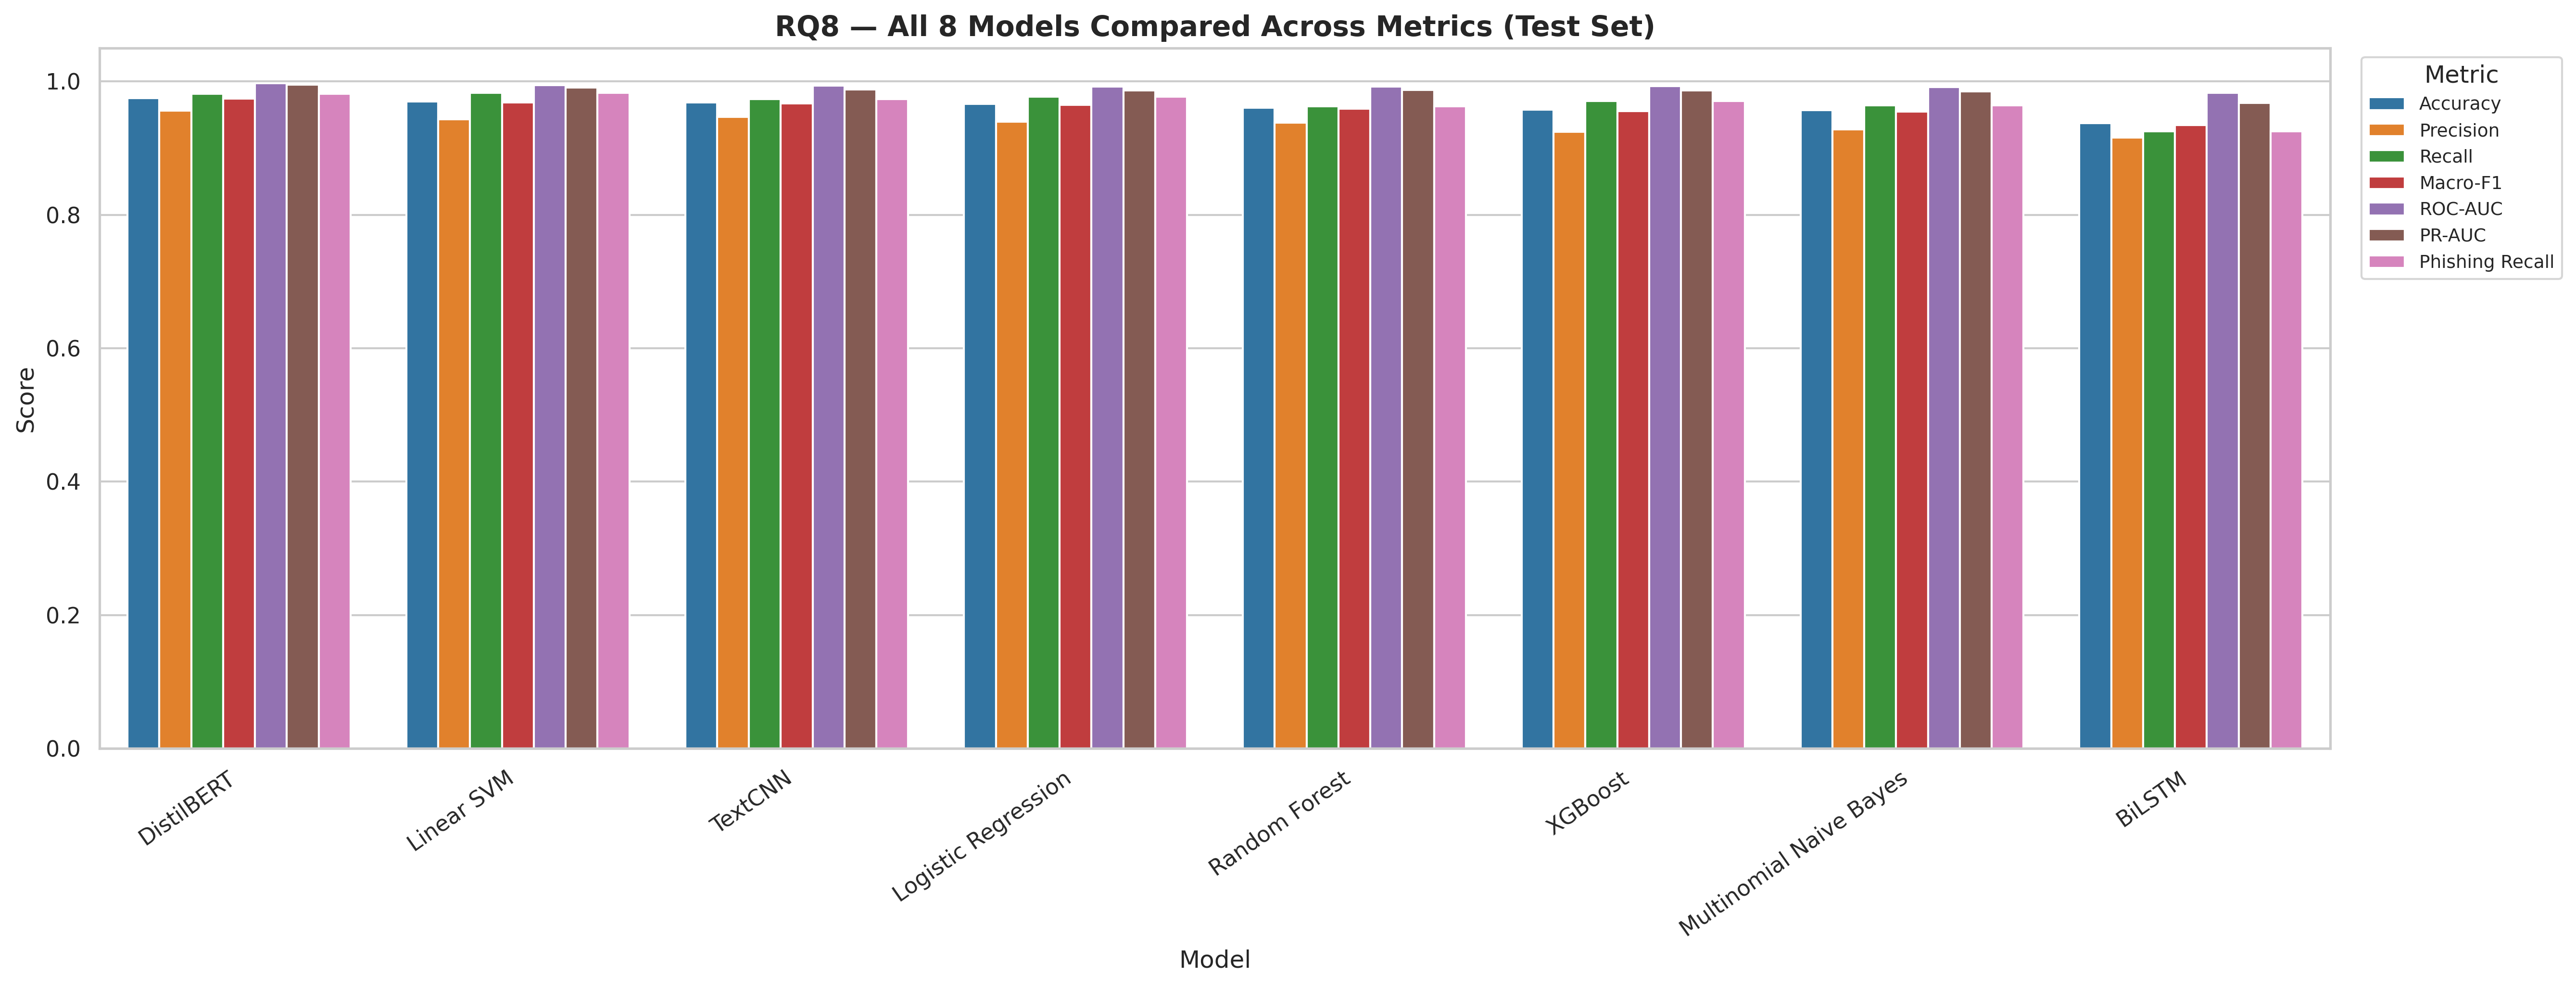

  ✓ Saved → rq8_grouped_bar_all_metrics.png
[2/3] ROC curve overlay...


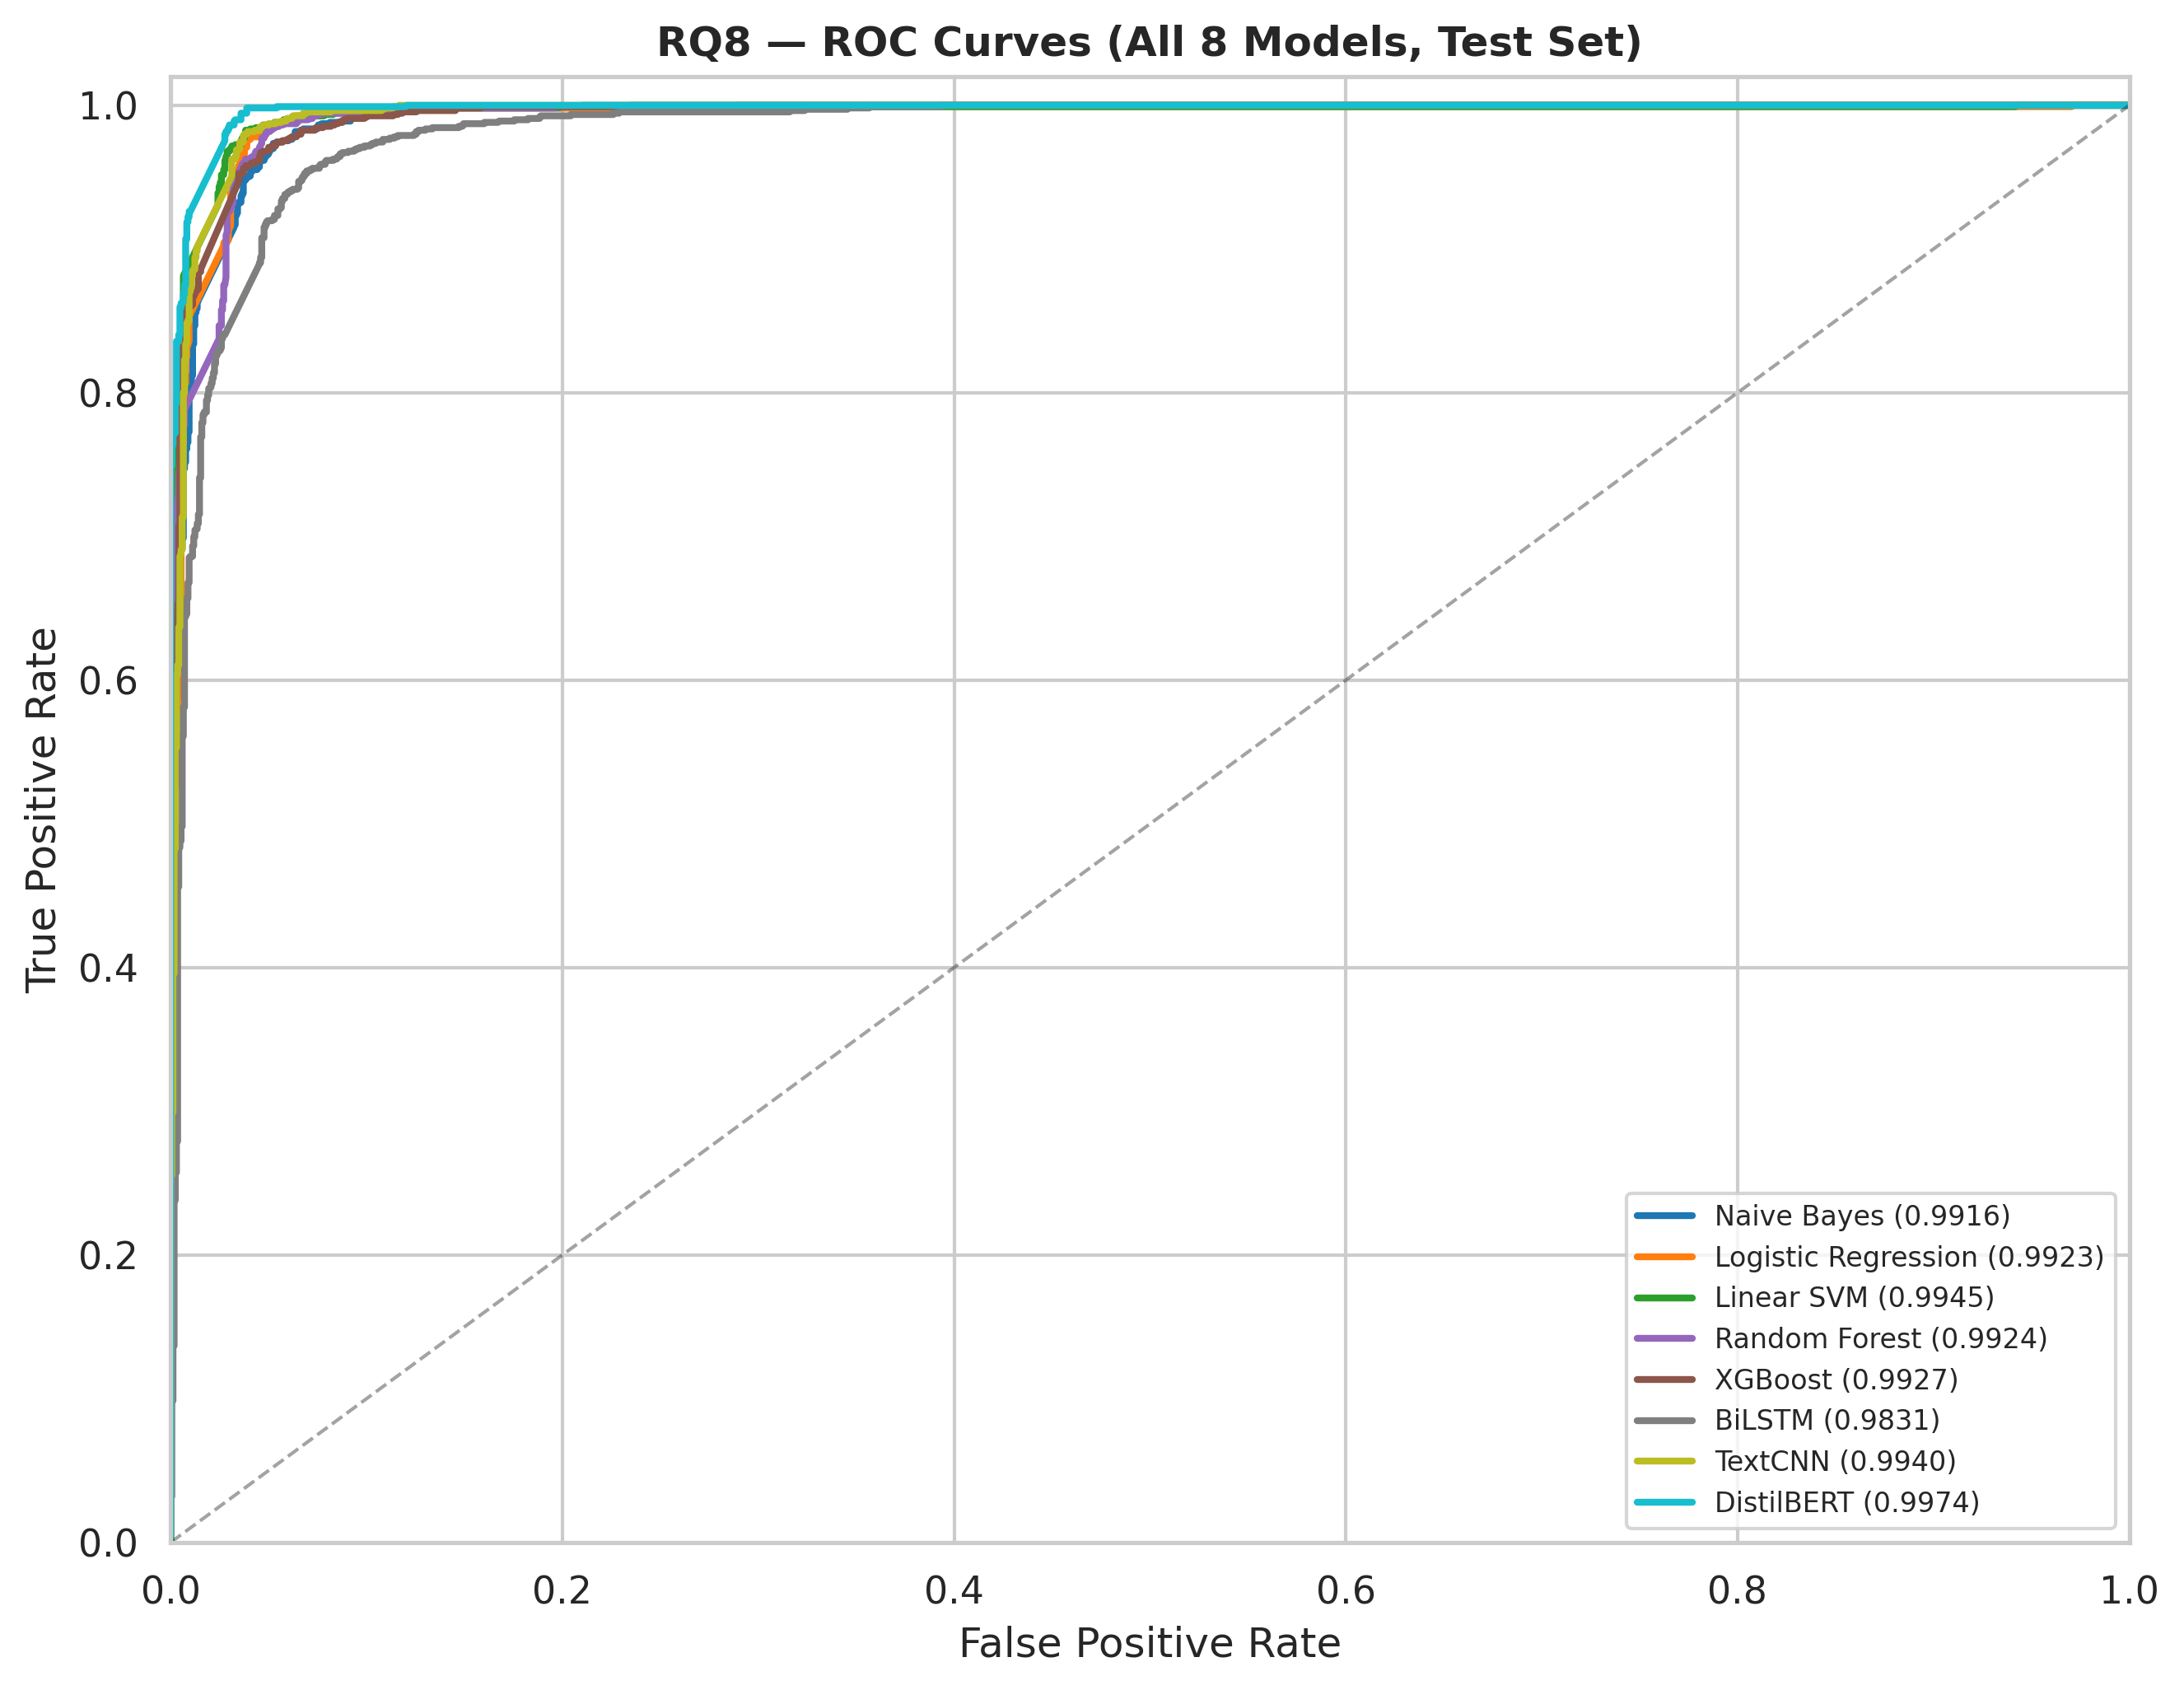

  ✓ Saved → rq8_roc_all_models_overlay.png
[3/3] PR curve overlay...


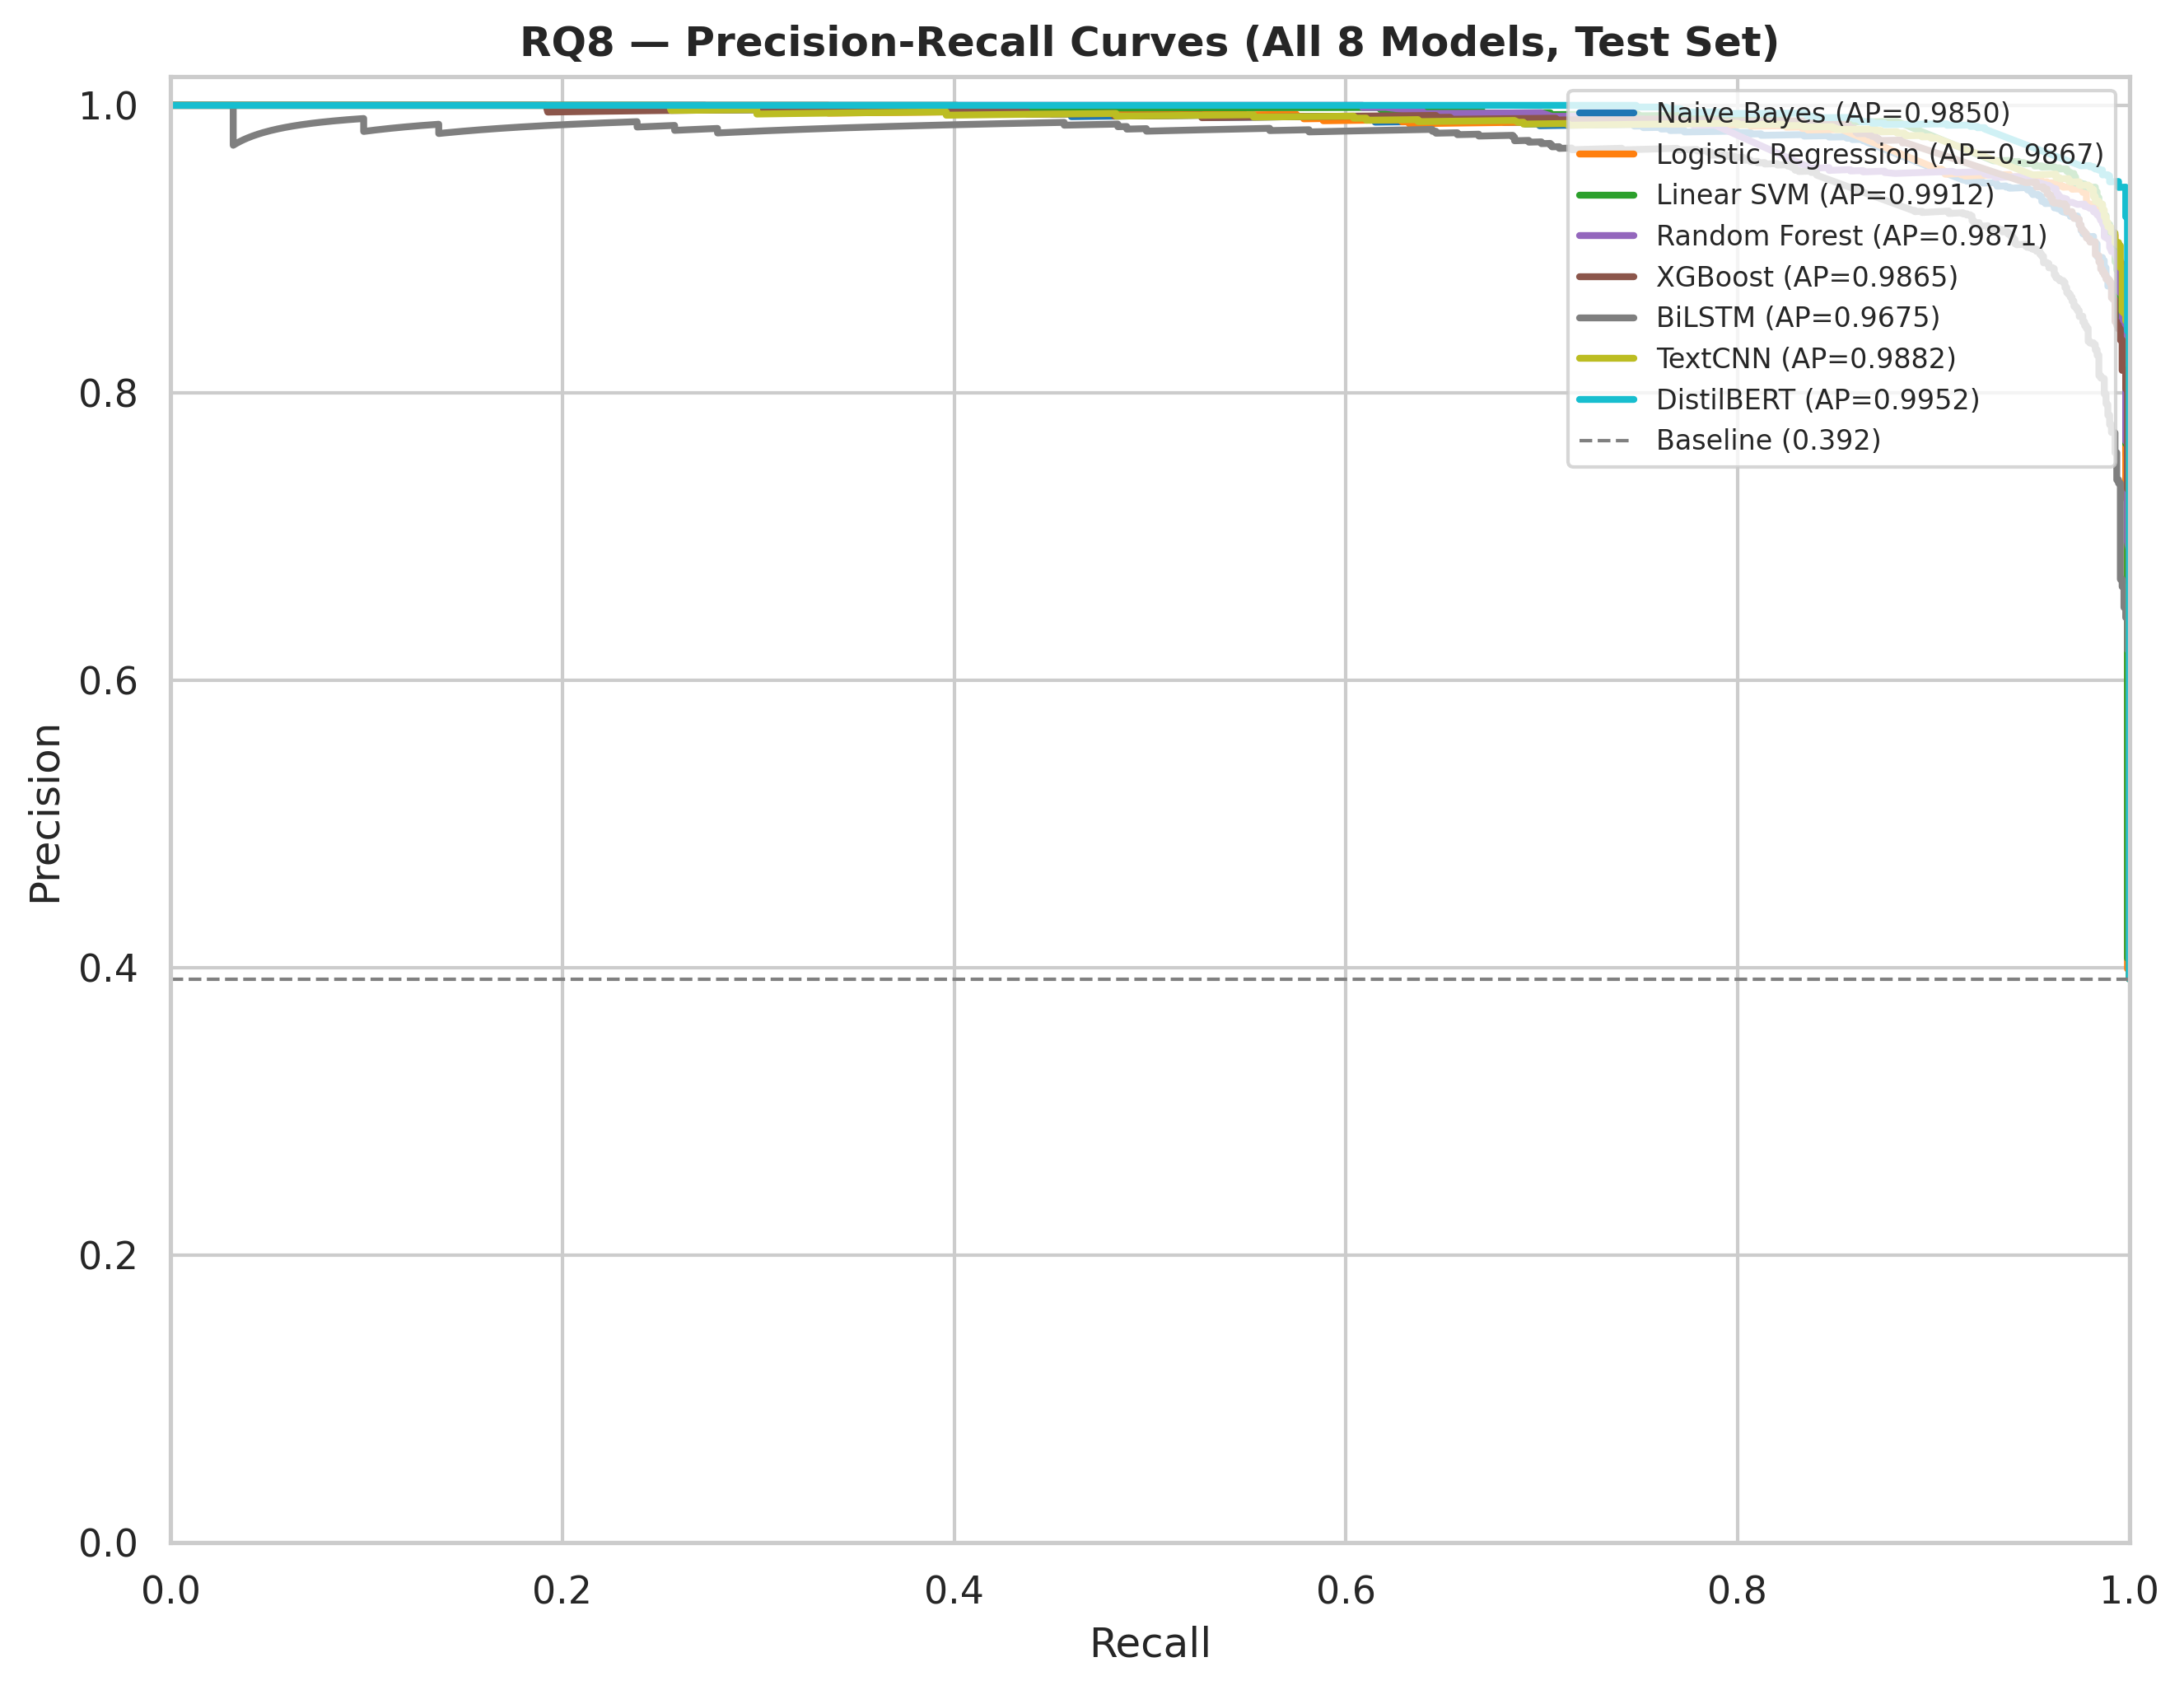

  ✓ Saved → rq8_pr_all_models_overlay.png

RQ8 — MASTER COMPARISON COMPLETE ✓

Results → /content/drive/MyDrive/NLP FINAL/rq8_master_evaluation/results/
  paper_table_rq8_master_comparison.csv   ← paste into Report Section 8
  master_metrics_full.csv
  best_model_per_metric.csv
  phishing_recall_ranking.csv
  experiment_config.csv

Diagrams → /content/drive/MyDrive/NLP FINAL/rq8_master_evaluation/diagrams/
  rq8_grouped_bar_all_metrics.png
  rq8_roc_all_models_overlay.png
  rq8_pr_all_models_overlay.png

Best Macro-F1 overall  : DistilBERT (0.9742)
Best Phishing Recall   : Linear SVM (0.9827)
  ↑ Operationally most important — missed phishing is costlier than false alarms

── Master Comparison Table (sorted by Macro-F1) ──


/tmp/ipykernel_21278/3563890515.py:270: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc":      datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),


,Model,Family,Stage,Accuracy,Precision,Recall,Macro-F1,ROC-AUC,PR-AUC,Phishing Recall
0,DistilBERT,Transformer,RQ6,0.9753,0.9564,0.9818,0.9742,0.9974,0.9952,0.9818
1,Linear SVM,Margin-based,RQ4,0.9699,0.9431,0.9827,0.9687,0.9945,0.9912,0.9827
2,TextCNN,Convolutional (Deep Learning),RQ5,0.9682,0.9468,0.9735,0.9668,0.9940,0.9882,0.9735
3,Logistic Regression,Linear,RQ4,0.9664,0.9395,0.9772,0.9650,0.9923,0.9867,0.9772
4,Random Forest,Tree ensemble (bagging),RQ4,0.9606,0.9386,0.9626,0.9589,0.9924,0.9871,0.9626
5,XGBoost,Tree ensemble (boosting),RQ4,0.9574,0.9244,0.9708,0.9557,0.9927,0.9865,0.9708
6,Multinomial Naive Bayes,Probabilistic,RQ4,0.9567,0.9280,0.9644,0.9549,0.9916,0.9850,0.9644
7,BiLSTM,Recurrent (Deep Learning),RQ5,0.9374,0.9160,0.9252,0.9344,0.9831,0.9675,0.9252



── Phishing Recall Ranking ──


,Model,Phishing Recall,Macro-F1,PR-AUC
1,Linear SVM,0.9827,0.9687,0.9912
0,DistilBERT,0.9818,0.9742,0.9952
3,Logistic Regression,0.9772,0.9650,0.9867
2,TextCNN,0.9735,0.9668,0.9882
5,XGBoost,0.9708,0.9557,0.9865
6,Multinomial Naive Bayes,0.9644,0.9549,0.9850
4,Random Forest,0.9626,0.9589,0.9871
7,BiLSTM,0.9252,0.9344,0.9675



Next step → RQ9 (Explainability: LIME + SHAP/attention)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PhishGuard AI — RQ8: Master Comparison Table & Full Evaluation
# READ-ONLY: loads CSVs from RQ4, RQ5, RQ6 — NO retraining
# 8 models: NB | LogReg | SVM | RF | XGBoost | BiLSTM | TextCNN | DistilBERT
# ═══════════════════════════════════════════════════════════════════════════════

# ═══ CELL 1 — Reproducibility Block ═══
import os, random, numpy as np, torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

print("✓ Reproducibility block applied (SEED=42)")


# ═══ CELL 2 — Drive mount + folder tree ═══
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR  = "/content/drive/MyDrive/NLP FINAL"
STAGE_DIR = os.path.join(BASE_DIR, "rq8_master_evaluation")

RESULTS_DIR  = os.path.join(STAGE_DIR, "results")
DIAGRAMS_DIR = os.path.join(STAGE_DIR, "diagrams")
LOGS_DIR     = os.path.join(STAGE_DIR, "logs")
MODELS_DIR   = os.path.join(STAGE_DIR, "models")

for folder in [RESULTS_DIR, DIAGRAMS_DIR, LOGS_DIR, MODELS_DIR]:
    os.makedirs(folder, exist_ok=True)

# Source paths (read-only)
PATHS = {
    "rq4_metrics": os.path.join(BASE_DIR, "rq4_classical_ml",  "results", "overall_metrics.csv"),
    "rq4_preds":   os.path.join(BASE_DIR, "rq4_classical_ml",  "results", "test_predictions.csv"),
    "rq5_metrics": os.path.join(BASE_DIR, "rq5_deep_learning", "results", "overall_metrics.csv"),
    "rq5_preds":   os.path.join(BASE_DIR, "rq5_deep_learning", "results", "test_predictions.csv"),
    "rq6_metrics": os.path.join(BASE_DIR, "rq6_transformer",   "results", "overall_metrics.csv"),
    "rq6_preds":   os.path.join(BASE_DIR, "rq6_transformer",   "results", "test_predictions.csv"),
}

for name, p in PATHS.items():
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing {name}: {p}\nComplete RQ4–RQ6 first.")

print(f"✓ STAGE_DIR : {STAGE_DIR}")
print("✓ All source CSVs found (read-only mode — no retraining)")


# ═══ CELL 3 — Install + imports ═══
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pandas", "matplotlib", "seaborn", "scikit-learn"])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from datetime import datetime
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

DPI = 300
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = DPI
plt.rcParams["savefig.dpi"] = DPI


# ═══ CELL 4 — Load & combine metrics from RQ4 / RQ5 / RQ6 ═══
rq4 = pd.read_csv(PATHS["rq4_metrics"]).assign(source_stage="RQ4")
rq5 = pd.read_csv(PATHS["rq5_metrics"]).assign(source_stage="RQ5")
rq6 = pd.read_csv(PATHS["rq6_metrics"]).assign(source_stage="RQ6")

master_raw = pd.concat([rq4, rq5, rq6], ignore_index=True)

METRIC_COLS = [
    "accuracy", "precision", "recall",
    "macro_f1", "roc_auc", "pr_auc", "phishing_recall",
]

# Paper-ready master table (8 models)
paper_table = master_raw[[
    "model_name", "model_family", "source_stage", *METRIC_COLS
]].copy()

paper_table.columns = [
    "Model", "Family", "Stage",
    "Accuracy", "Precision", "Recall",
    "Macro-F1", "ROC-AUC", "PR-AUC", "Phishing Recall",
]

paper_table = paper_table.sort_values("Macro-F1", ascending=False).reset_index(drop=True)

master_path = os.path.join(RESULTS_DIR, "paper_table_rq8_master_comparison.csv")
paper_table.to_csv(master_path, index=False)

print(f"✓ Master table: {len(paper_table)} models")
display(paper_table)


# ═══ CELL 5 — Load test predictions (for ROC / PR curves — no model reload) ═══
rq4_preds = pd.read_csv(PATHS["rq4_preds"])
rq5_preds = pd.read_csv(PATHS["rq5_preds"])
rq6_preds = pd.read_csv(PATHS["rq6_preds"])

y_true = rq4_preds["y_true"].values
assert np.array_equal(y_true, rq5_preds["y_true"].values), "y_true mismatch RQ4 vs RQ5"
assert np.array_equal(y_true, rq6_preds["y_true"].values), "y_true mismatch RQ4 vs RQ6"

# Map: display label → probability column
PROB_MAP = {
    "Naive Bayes":           ("rq4", "naive_bayes_phishing_prob"),
    "Logistic Regression":   ("rq4", "logistic_regression_phishing_prob"),
    "Linear SVM":            ("rq4", "linear_svm_phishing_prob"),
    "Random Forest":         ("rq4", "random_forest_phishing_prob"),
    "XGBoost":               ("rq4", "xgboost_phishing_prob"),
    "BiLSTM":                ("rq5", "bilstm_phishing_prob"),
    "TextCNN":               ("rq5", "textcnn_phishing_prob"),
    "DistilBERT":            ("rq6", "distilbert_phishing_prob"),
}

pred_frames = {"rq4": rq4_preds, "rq5": rq5_preds, "rq6": rq6_preds}

prob_data = {}
for model_label, (stage, col) in PROB_MAP.items():
    if col not in pred_frames[stage].columns:
        raise KeyError(f"Missing column {col} in {stage} test_predictions.csv")
    prob_data[model_label] = pred_frames[stage][col].values

print(f"✓ Loaded test predictions for {len(prob_data)} models  (n={len(y_true):,})")


# ═══ CELL 6 — DIAGRAM 1: Grouped bar chart (all 8 models × all metrics) ═══
print("\n[1/3] Grouped bar chart...")

plot_df = paper_table.copy()
model_order = plot_df["Model"].tolist()

melted = plot_df.melt(
    id_vars=["Model"],
    value_vars=["Accuracy", "Precision", "Recall", "Macro-F1",
                "ROC-AUC", "PR-AUC", "Phishing Recall"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(
    data=melted,
    x="Model", y="Score", hue="Metric",
    order=model_order,
    palette="tab10",
    ax=ax,
)
ax.set_title("RQ8 — All 8 Models Compared Across Metrics (Test Set)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=35)
plt.setp(ax.get_xticklabels(), ha="right")
ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
bar_path = os.path.join(DIAGRAMS_DIR, "rq8_grouped_bar_all_metrics.png")
plt.savefig(bar_path, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()
print(f"  ✓ Saved → rq8_grouped_bar_all_metrics.png")


# ═══ CELL 7 — DIAGRAM 2: ROC curve overlay (all 8 models) ═══
print("[2/3] ROC curve overlay...")

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(prob_data)))

roc_summary = []
for (label, probs), color in zip(prob_data.items(), colors):
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{label} ({roc_auc_val:.4f})")
    roc_summary.append({"Model": label, "ROC-AUC (recomputed)": round(roc_auc_val, 4)})

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("RQ8 — ROC Curves (All 8 Models, Test Set)", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
roc_path = os.path.join(DIAGRAMS_DIR, "rq8_roc_all_models_overlay.png")
plt.savefig(roc_path, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()
print(f"  ✓ Saved → rq8_roc_all_models_overlay.png")


# ═══ CELL 8 — DIAGRAM 3: PR curve overlay (all 8 models) ═══
print("[3/3] PR curve overlay...")

fig, ax = plt.subplots(figsize=(9, 7))
pr_summary = []
baseline = y_true.mean()

for (label, probs), color in zip(prob_data.items(), colors):
    prec, rec, _ = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)
    ax.plot(rec, prec, lw=2, color=color, label=f"{label} (AP={ap:.4f})")
    pr_summary.append({"Model": label, "PR-AUC (recomputed)": round(ap, 4)})

ax.axhline(baseline, color="gray", linestyle="--", lw=1,
           label=f"Baseline ({baseline:.3f})")
ax.set_xlim([0, 1]); ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("RQ8 — Precision-Recall Curves (All 8 Models, Test Set)", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
pr_path = os.path.join(DIAGRAMS_DIR, "rq8_pr_all_models_overlay.png")
plt.savefig(pr_path, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()
print(f"  ✓ Saved → rq8_pr_all_models_overlay.png")


# ═══ CELL 9 — Additional results CSVs ═══
# Full master with model_key if available
master_full = master_raw[[
    "model_key", "model_name", "model_family", "source_stage",
    "eval_set", *METRIC_COLS
]].sort_values("macro_f1", ascending=False)
master_full.to_csv(os.path.join(RESULTS_DIR, "master_metrics_full.csv"), index=False)

pd.DataFrame(roc_summary).to_csv(os.path.join(RESULTS_DIR, "roc_auc_verification.csv"), index=False)
pd.DataFrame(pr_summary).to_csv(os.path.join(RESULTS_DIR, "pr_auc_verification.csv"), index=False)

# Best model per metric
best_per_metric_rows = []
for col in METRIC_COLS:
    row = master_raw.loc[master_raw[col].idxmax()]
    best_per_metric_rows.append({
        "metric": col,
        "best_model": row["model_name"],
        "best_score": row[col],
        "family": row["model_family"],
        "stage": row["source_stage"],
    })
best_df = pd.DataFrame(best_per_metric_rows)
best_df.to_csv(os.path.join(RESULTS_DIR, "best_model_per_metric.csv"), index=False)

# Operational note — Phishing Recall ranking
phishing_rank = paper_table[["Model", "Phishing Recall", "Macro-F1", "PR-AUC"]].sort_values(
    "Phishing Recall", ascending=False
)
phishing_rank.to_csv(os.path.join(RESULTS_DIR, "phishing_recall_ranking.csv"), index=False)


# ═══ CELL 10 — experiment_config.csv ═══
config = {
    "project":            "PhishGuard AI",
    "stage":              "RQ8 — Master Comparison & Full Evaluation",
    "timestamp_utc":      datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
    "seed":               SEED,
    "mode":               "READ-ONLY (no retraining)",
    "sources":            "RQ4 + RQ5 + RQ6 overall_metrics.csv & test_predictions.csv",
    "total_models":       8,
    "eval_set":           "test",
    "metrics_reported":   ", ".join(METRIC_COLS),
    "operational_metric": "phishing_recall (most important for deployment)",
    "diagram_dpi":        DPI,
    "diagrams":           "grouped_bar, roc_overlay, pr_overlay",
    "python_version":     platform.python_version(),
    "pandas_version":     pd.__version__,
}
pd.DataFrame(list(config.items()), columns=["parameter", "value"]).to_csv(
    os.path.join(RESULTS_DIR, "experiment_config.csv"), index=False
)


# ═══ CELL 11 — Final summary ═══
best_overall = paper_table.iloc[0]
best_phishing = paper_table.sort_values("Phishing Recall", ascending=False).iloc[0]

print("\n" + "=" * 70)
print("RQ8 — MASTER COMPARISON COMPLETE ✓")
print("=" * 70)
print(f"\nResults → {RESULTS_DIR}/")
print("  paper_table_rq8_master_comparison.csv   ← paste into Report Section 8")
print("  master_metrics_full.csv")
print("  best_model_per_metric.csv")
print("  phishing_recall_ranking.csv")
print("  experiment_config.csv")
print(f"\nDiagrams → {DIAGRAMS_DIR}/")
print("  rq8_grouped_bar_all_metrics.png")
print("  rq8_roc_all_models_overlay.png")
print("  rq8_pr_all_models_overlay.png")
print(f"\nBest Macro-F1 overall  : {best_overall['Model']} ({best_overall['Macro-F1']})")
print(f"Best Phishing Recall   : {best_phishing['Model']} ({best_phishing['Phishing Recall']})")
print("  ↑ Operationally most important — missed phishing is costlier than false alarms")
print("\n── Master Comparison Table (sorted by Macro-F1) ──")
display(paper_table)
print("\n── Phishing Recall Ranking ──")
display(phishing_rank)
print("\nNext step → RQ9 (Explainability: LIME + SHAP/attention)")
print("=" * 70)